In [19]:
import pandas as pd
from CoolProp.CoolProp import PropsSI
import matplotlib.pyplot as plt
import numpy as np

df=pd.read_excel(r'C:\Users\User\Desktop\단조실\4.자연강제대류\convection_frame2.xlsx')


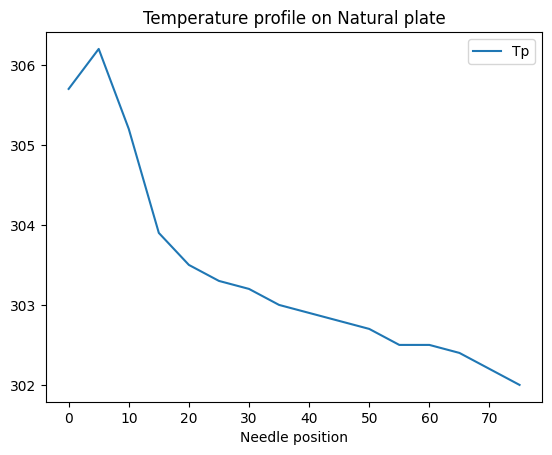

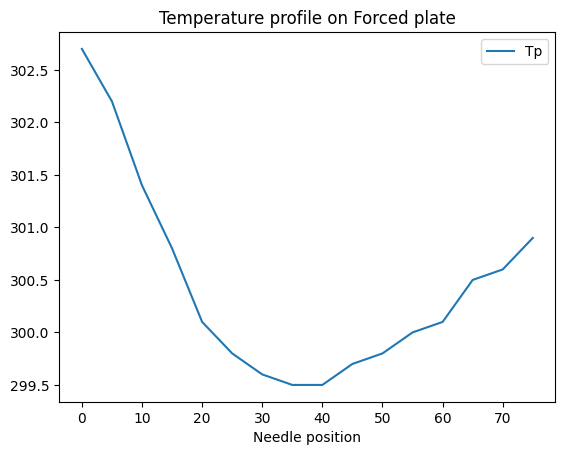

In [20]:


plt.plot(df['position'],df['Tp'],label='Tp')
#plt.axhline(y=df['Ts'].iloc[0],label='Ts',color='red')
plt.xlabel('Needle position')
plt.title('Temperature profile on Natural plate')
plt.legend()
plt.show()
plt.close()


plt.plot(df['position3'],df['Tp3'],label='Tp')
#plt.axhline(y=df['Ts3'].iloc[0],label='Ts',color='red')
plt.xlabel('Needle position')
plt.title('Temperature profile on Forced plate')
plt.legend()
plt.show()


df['Tout']=np.trapezoid(df['Tp'],df['position'])/(df['position'].iloc[-1]-df['position'].iloc[0])

df['Tout3']=np.trapezoid(df['Tp3'],df['position3'])/(df['position3'].iloc[-1]-df['position3'].iloc[0])



def logmean(a,b):
    return (a-b)/np.log(a/b)

df['Tlm']=logmean(df['Tin'],df['Tout'])

df['Tlm3']=logmean(df['Tin3'],df['Tout3'])



df['h']=-df['q']/(df['A']*(df['Tin']-df['Ts']))

df['h3']=-df['q3']/(df['A3']*(df['Tin3']-df['Ts3']))


dt1=(df['Tin']+df['Ts'])/2

dt3=(df['Tin3']+df['Ts3'])/2



df['k']=dt1.apply(lambda T:PropsSI('L','T',T,'P',101325,'Air'))

df['k3']=dt3.apply(lambda T:PropsSI('L','T',T,'P',101325,'Air'))


df['Nu']=(df['h']*df['D'])/df['k']

df['Nu3']=(df['h3']*df['D3'])/df['k3']

df['mu']=dt3.apply(lambda T:PropsSI('V','T',T,'P',101325,'Air'))
df['c']=dt3.apply(lambda T:PropsSI('C','T',T,'P',101325,'Air'))
rho=dt3.apply(lambda T:PropsSI('D','T',T,'P',101325,'Air'))
df['Re']=(rho*df['u']*df['D3'])/df['mu']
df['Pr']=df['mu']*df['c']/df['k3']

df['f']=df['Re'].apply(lambda R: 0.046*R**(-0.2) if R>4000 else 16/R) 
df['Nuu']=df['f']*df['Re']*(df['Pr']**(1/3))/2


df.to_excel(r'C:\Users\User\Desktop\단조실\4.자연강제대류\convection_result2.xlsx')


In [21]:
Tm1=np.mean(29.7,95.1)
Tm2=np.mean()

TypeError: integer argument expected, got float